# HLLRD South-East Reconstruction Check

This notebook overlays original ADS-B tracks with HLLRD reconstructed paths for 30 flights in an 8x4 subplot grid. It also summarizes reconstruction error, including maximum cross-track error.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "hllrd").exists():
            return candidate
    raise RuntimeError("Could not find the project root.")


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from hllrd.data import trim_tracks_from_anchor  # noqa: E402
from hllrd.elastic_fpca import load_elastic_fpca_result  # noqa: E402
from hllrd.fit import load_fit_result  # noqa: E402
from hllrd.geometry import LocalProjection  # noqa: E402
from hllrd.matrix import load_matrix_artifact  # noqa: E402
from scenario.trajectory_compressor.io import load_raw_adsb, split_tracks_by_gap  # noqa: E402

## Configuration

In [2]:
ARTIFACT_DIR = PROJECT_ROOT / "data" / "hllrd" / "south-east"
MATRIX_PATH = ARTIFACT_DIR / "matrix_SE_from_merge.npz"
MODEL_PATH = ARTIFACT_DIR / "model_from_merge_L40_K6.npz"
ELASTIC_FPCA_PATH = ARTIFACT_DIR / "elastic_fpca_from_merge_L40_K6.npz"

# When None, the notebook uses the raw ADS-B directory recorded in the matrix metadata.
RAW_ADSB_DIR: Path | None = None
LOAD_RAW_ADSB = True
RAW_ADSB_PROCESSES = 1
SPLIT_GAP_SECONDS = 25 * 60

N_FLIGHTS = 30
ROWS = 8
COLS = 4

# Options: "worst_max_error", "first", "random".
SELECTION = "worst_max_error"
RANDOM_SEED = 7

SAVE_FIGURE_PATH = ARTIFACT_DIR / "reconstruction_check_30_flights.png"

## Load HLLRD Artifacts

In [3]:
matrix = load_matrix_artifact(MATRIX_PATH)
model = load_fit_result(MODEL_PATH)
elastic_fpca = load_elastic_fpca_result(ELASTIC_FPCA_PATH) if ELASTIC_FPCA_PATH.exists() else None

if matrix.X.shape != model.reconstruction.shape:
    raise RuntimeError(
        f"Matrix shape {matrix.X.shape} does not match reconstruction shape {model.reconstruction.shape}."
    )

projection = LocalProjection(matrix.origin_lat_deg, matrix.origin_lon_deg)
reconstructed_offsets_m = model.column_center[None, :] + model.reconstruction
cross_track_error_m = matrix.X - reconstructed_offsets_m

print(f"Matrix: {MATRIX_PATH.relative_to(PROJECT_ROOT)}")
print(f"Model:  {MODEL_PATH.relative_to(PROJECT_ROOT)}")
print(f"Elastic FPCA: {ELASTIC_FPCA_PATH.relative_to(PROJECT_ROOT) if elastic_fpca else 'not loaded'}")
print(f"Flights: {len(matrix.flight_ids):,}; stations: {matrix.X.shape[1]:,}; events: {len(model.events):,}")
print(f"Explained fraction: {model.explained_fraction:.4f}")
if elastic_fpca is None:
    warnings.warn("Elastic FPCA artifact was not found; hPCA/vPCA score annotations will be omitted.")

Matrix: data/hllrd/south-east/matrix_SE_from_merge.npz
Model:  data/hllrd/south-east/model_from_merge_L40_K6.npz
Elastic FPCA: data/hllrd/south-east/elastic_fpca_from_merge_L40_K6.npz
Flights: 208; stations: 200; events: 6
Explained fraction: 0.9928


## Geometry Helpers

In [4]:
def xy_from_normal_offsets(offsets_m: np.ndarray) -> np.ndarray:
    offsets = np.asarray(offsets_m, dtype=float)
    return matrix.reference_xy_m + offsets[:, None] * matrix.normals_xy


def latlon_from_xy(xy_m: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    lat, lon = projection.unproject(xy_m[:, 0], xy_m[:, 1])
    return np.asarray(lat, dtype=float), np.asarray(lon, dtype=float)


def matrix_original_latlon(row_index: int) -> tuple[np.ndarray, np.ndarray]:
    return latlon_from_xy(xy_from_normal_offsets(matrix.X[row_index]))


def reconstructed_latlon(row_index: int) -> tuple[np.ndarray, np.ndarray]:
    return latlon_from_xy(xy_from_normal_offsets(reconstructed_offsets_m[row_index]))


def template_latlon() -> tuple[np.ndarray, np.ndarray]:
    return latlon_from_xy(xy_from_normal_offsets(model.column_center))


def format_score_pair(values: np.ndarray) -> str:
    pair = np.asarray(values, dtype=float)[:2]
    finite = pair[np.isfinite(pair)]
    if finite.size == 0:
        return "[]"

    abs_values = np.abs(finite)
    max_abs = float(np.max(abs_values))
    positive = abs_values[abs_values > 0.0]
    min_positive = float(np.min(positive)) if positive.size else max_abs
    use_scientific = max_abs >= 1.0e4 or (min_positive > 0.0 and max_abs / min_positive >= 1.0e4)

    def format_one(value: float) -> str:
        if not np.isfinite(value):
            return "nan"
        magnitude = abs(float(value))
        if use_scientific:
            return f"{value:.2e}"
        if magnitude >= 100.0:
            return f"{value:.0f}"
        if magnitude >= 10.0:
            return f"{value:.1f}"
        return f"{value:.2f}"

    return "[" + ", ".join(format_one(float(value)) for value in pair) + "]"


def pca_score_label(row_index: int, station_index: int) -> str:
    if elastic_fpca is None:
        return ""

    candidates = []
    for event in elastic_fpca.events:
        active_matches = np.flatnonzero(np.asarray(event.active_rows, dtype=int) == int(row_index))
        if active_matches.size == 0:
            continue
        inside = int(event.start) <= int(station_index) < int(event.end)
        distance = 0 if inside else min(abs(int(station_index) - int(event.start)), abs(int(station_index) - int(event.end - 1)))
        candidates.append((0 if inside else 1, distance, event, int(active_matches[0])))

    if not candidates:
        return "hPCA=n/a\nvPCA=n/a"

    _priority, _distance, event, local_index = min(candidates, key=lambda item: (item[0], item[1], item[2].event_index))
    h_scores = event.horizontal_coefficients[local_index, :2]
    v_scores = event.vertical_coefficients[local_index, :2]
    return f"E{event.event_index} hPCA={format_score_pair(h_scores)}\nvPCA={format_score_pair(v_scores)}"


def axis_equal_lonlat(ax) -> None:
    lat0 = float(matrix.origin_lat_deg)
    try:
        ax.set_aspect(1.0 / max(np.cos(np.radians(lat0)), 1.0e-6), adjustable="box")
    except Exception:
        ax.set_aspect("equal", adjustable="box")

## Optional Raw ADS-B Tracks

In [5]:
def raw_adsb_dir_from_matrix() -> Path:
    if RAW_ADSB_DIR is not None:
        return Path(RAW_ADSB_DIR)
    raw_dir = matrix.metadata.get("raw_adsb_dir")
    if not raw_dir:
        raise RuntimeError("Matrix metadata does not include raw_adsb_dir. Set RAW_ADSB_DIR explicitly.")
    return Path(str(raw_dir))


def load_trimmed_raw_tracks() -> dict[str, pd.DataFrame]:
    source_dir = raw_adsb_dir_from_matrix()
    tracks = load_raw_adsb(source_dir, RAW_ADSB_PROCESSES)
    tracks = split_tracks_by_gap(tracks, SPLIT_GAP_SECONDS)
    tracks = tracks.loc[tracks["flight_id"].astype(str).isin(set(matrix.flight_ids))].copy()

    trim_info = matrix.metadata.get("trim", {})
    if trim_info:
        tracks = trim_tracks_from_anchor(
            tracks,
            anchor_lat_deg=float(trim_info.get("refined_anchor_lat_deg", trim_info["coarse_anchor_lat_deg"])),
            anchor_lon_deg=float(trim_info.get("refined_anchor_lon_deg", trim_info["coarse_anchor_lon_deg"])),
            max_anchor_distance_nm=float(trim_info.get("max_anchor_distance_nm", 15.0)),
            min_points_after_anchor=int(matrix.metadata.get("config", {}).get("min_points_per_flight", 3)),
            refine_anchor=False,
        ).tracks

    result: dict[str, pd.DataFrame] = {}
    for flight_id, flight in tracks.groupby("flight_id", sort=False):
        ordered = flight.sort_values("time", kind="stable")
        if len(ordered) >= 2:
            result[str(flight_id)] = ordered.loc[:, ["time", "lat", "lon"]].copy()
    return result


raw_tracks_by_flight: dict[str, pd.DataFrame] = {}
if LOAD_RAW_ADSB:
    try:
        raw_tracks_by_flight = load_trimmed_raw_tracks()
        print(f"Loaded raw ADS-B tracks for {len(raw_tracks_by_flight):,} matrix flights.")
    except Exception as exc:
        warnings.warn(f"Raw ADS-B loading failed; falling back to matrix-derived original paths: {exc}")

if not raw_tracks_by_flight:
    print("Using matrix-derived original paths instead of raw ADS-B polylines.")

Loaded raw ADS-B tracks for 208 matrix flights.


## Reconstruction Error Summary

In [6]:
abs_error_m = np.abs(cross_track_error_m)

per_flight_error = pd.DataFrame(
    {
        "row_index": np.arange(len(matrix.flight_ids), dtype=int),
        "flight_id": list(matrix.flight_ids),
        "mean_abs_cross_track_error_m": np.mean(abs_error_m, axis=1),
        "rmse_cross_track_error_m": np.sqrt(np.mean(cross_track_error_m * cross_track_error_m, axis=1)),
        "median_abs_cross_track_error_m": np.median(abs_error_m, axis=1),
        "p95_abs_cross_track_error_m": np.percentile(abs_error_m, 95, axis=1),
        "max_abs_cross_track_error_m": np.max(abs_error_m, axis=1),
        "signed_error_at_max_m": cross_track_error_m[np.arange(cross_track_error_m.shape[0]), np.argmax(abs_error_m, axis=1)],
        "station_at_max_error": np.argmax(abs_error_m, axis=1),
    }
)

overall_error = pd.DataFrame(
    [
        {
            "flight_count": len(matrix.flight_ids),
            "station_count": matrix.X.shape[1],
            "mean_abs_cross_track_error_m": float(np.mean(abs_error_m)),
            "rmse_cross_track_error_m": float(np.sqrt(np.mean(cross_track_error_m * cross_track_error_m))),
            "median_abs_cross_track_error_m": float(np.median(abs_error_m)),
            "p95_abs_cross_track_error_m": float(np.percentile(abs_error_m, 95)),
            "max_abs_cross_track_error_m": float(np.max(abs_error_m)),
            "flight_id_at_max_error": per_flight_error.loc[per_flight_error["max_abs_cross_track_error_m"].idxmax(), "flight_id"],
            "station_at_max_error": int(np.unravel_index(np.argmax(abs_error_m), abs_error_m.shape)[1]),
        }
    ]
)

display(overall_error.style.format(precision=3))
display(
    per_flight_error.sort_values("max_abs_cross_track_error_m", ascending=False)
    .head(10)
    .style.format(precision=3)
)

,flight_count,station_count,mean_abs_cross_track_error_m,rmse_cross_track_error_m,median_abs_cross_track_error_m,p95_abs_cross_track_error_m,max_abs_cross_track_error_m,flight_id_at_max_error,station_at_max_error
0,208,200,76.856,158.365,29.975,307.950,2682.406,AAL362M1ab1d28,199


,row_index,flight_id,mean_abs_cross_track_error_m,rmse_cross_track_error_m,median_abs_cross_track_error_m,p95_abs_cross_track_error_m,max_abs_cross_track_error_m,signed_error_at_max_m,station_at_max_error
104,104,AAL362M1ab1d28,137.405,368.586,38.696,447.244,2682.406,-2682.406,199
19,19,AAL1486M1acf849,166.974,389.274,66.597,593.747,2682.014,-2682.014,197
134,134,ENY4125M2a1a5cf,247.959,492.469,100.576,802.849,2680.666,-2680.666,197
203,203,UPS5333M1a3918f,155.696,379.452,66.552,465.150,2678.698,-2678.698,199
205,205,UPS5765M1a06815,131.834,366.978,46.622,407.679,2678.216,-2678.216,199
7,7,AAL1122M1a32bf3,205.914,485.155,31.884,689.729,2674.787,-2674.787,199
147,147,JIA5127M2a65b64,77.679,229.019,38.447,264.267,2563.350,-2563.350,156
18,18,AAL1378M1ac77d3,157.797,368.642,45.156,529.670,2314.110,-2314.110,199
33,33,AAL1747M1ac79c7,58.410,181.400,22.751,206.627,1995.632,-1995.632,156
109,109,AAL802M1a0d374,105.240,233.634,37.629,392.495,1913.791,-1913.791,156


## Select 30 Flights

In [7]:
def select_flights() -> pd.DataFrame:
    if N_FLIGHTS > ROWS * COLS:
        raise ValueError("N_FLIGHTS must fit inside ROWS * COLS.")
    if SELECTION == "worst_max_error":
        selected = per_flight_error.sort_values("max_abs_cross_track_error_m", ascending=False).head(N_FLIGHTS)
    elif SELECTION == "first":
        selected = per_flight_error.sort_values("row_index", ascending=True).head(N_FLIGHTS)
    elif SELECTION == "random":
        selected = per_flight_error.sample(n=N_FLIGHTS, random_state=RANDOM_SEED)
    else:
        raise ValueError(f"Unknown SELECTION: {SELECTION!r}")
    return selected.sort_values("max_abs_cross_track_error_m", ascending=False).reset_index(drop=True)


selected_flights = select_flights()
display(selected_flights.style.format(precision=3))

,row_index,flight_id,mean_abs_cross_track_error_m,rmse_cross_track_error_m,median_abs_cross_track_error_m,p95_abs_cross_track_error_m,max_abs_cross_track_error_m,signed_error_at_max_m,station_at_max_error
0,104,AAL362M1ab1d28,137.405,368.586,38.696,447.244,2682.406,-2682.406,199
1,19,AAL1486M1acf849,166.974,389.274,66.597,593.747,2682.014,-2682.014,197
2,134,ENY4125M2a1a5cf,247.959,492.469,100.576,802.849,2680.666,-2680.666,197
3,203,UPS5333M1a3918f,155.696,379.452,66.552,465.150,2678.698,-2678.698,199
4,205,UPS5765M1a06815,131.834,366.978,46.622,407.679,2678.216,-2678.216,199
5,7,AAL1122M1a32bf3,205.914,485.155,31.884,689.729,2674.787,-2674.787,199
6,147,JIA5127M2a65b64,77.679,229.019,38.447,264.267,2563.350,-2563.350,156
7,18,AAL1378M1ac77d3,157.797,368.642,45.156,529.670,2314.110,-2314.110,199
8,33,AAL1747M1ac79c7,58.410,181.400,22.751,206.627,1995.632,-1995.632,156
9,109,AAL802M1a0d374,105.240,233.634,37.629,392.495,1913.791,-1913.791,156


## Original ADS-B Tracks vs Reconstructed Paths

Saved figure to /Volumes/CrucialX/project-rustlingtree/data/hllrd/south-east/reconstruction_check_30_flights.png


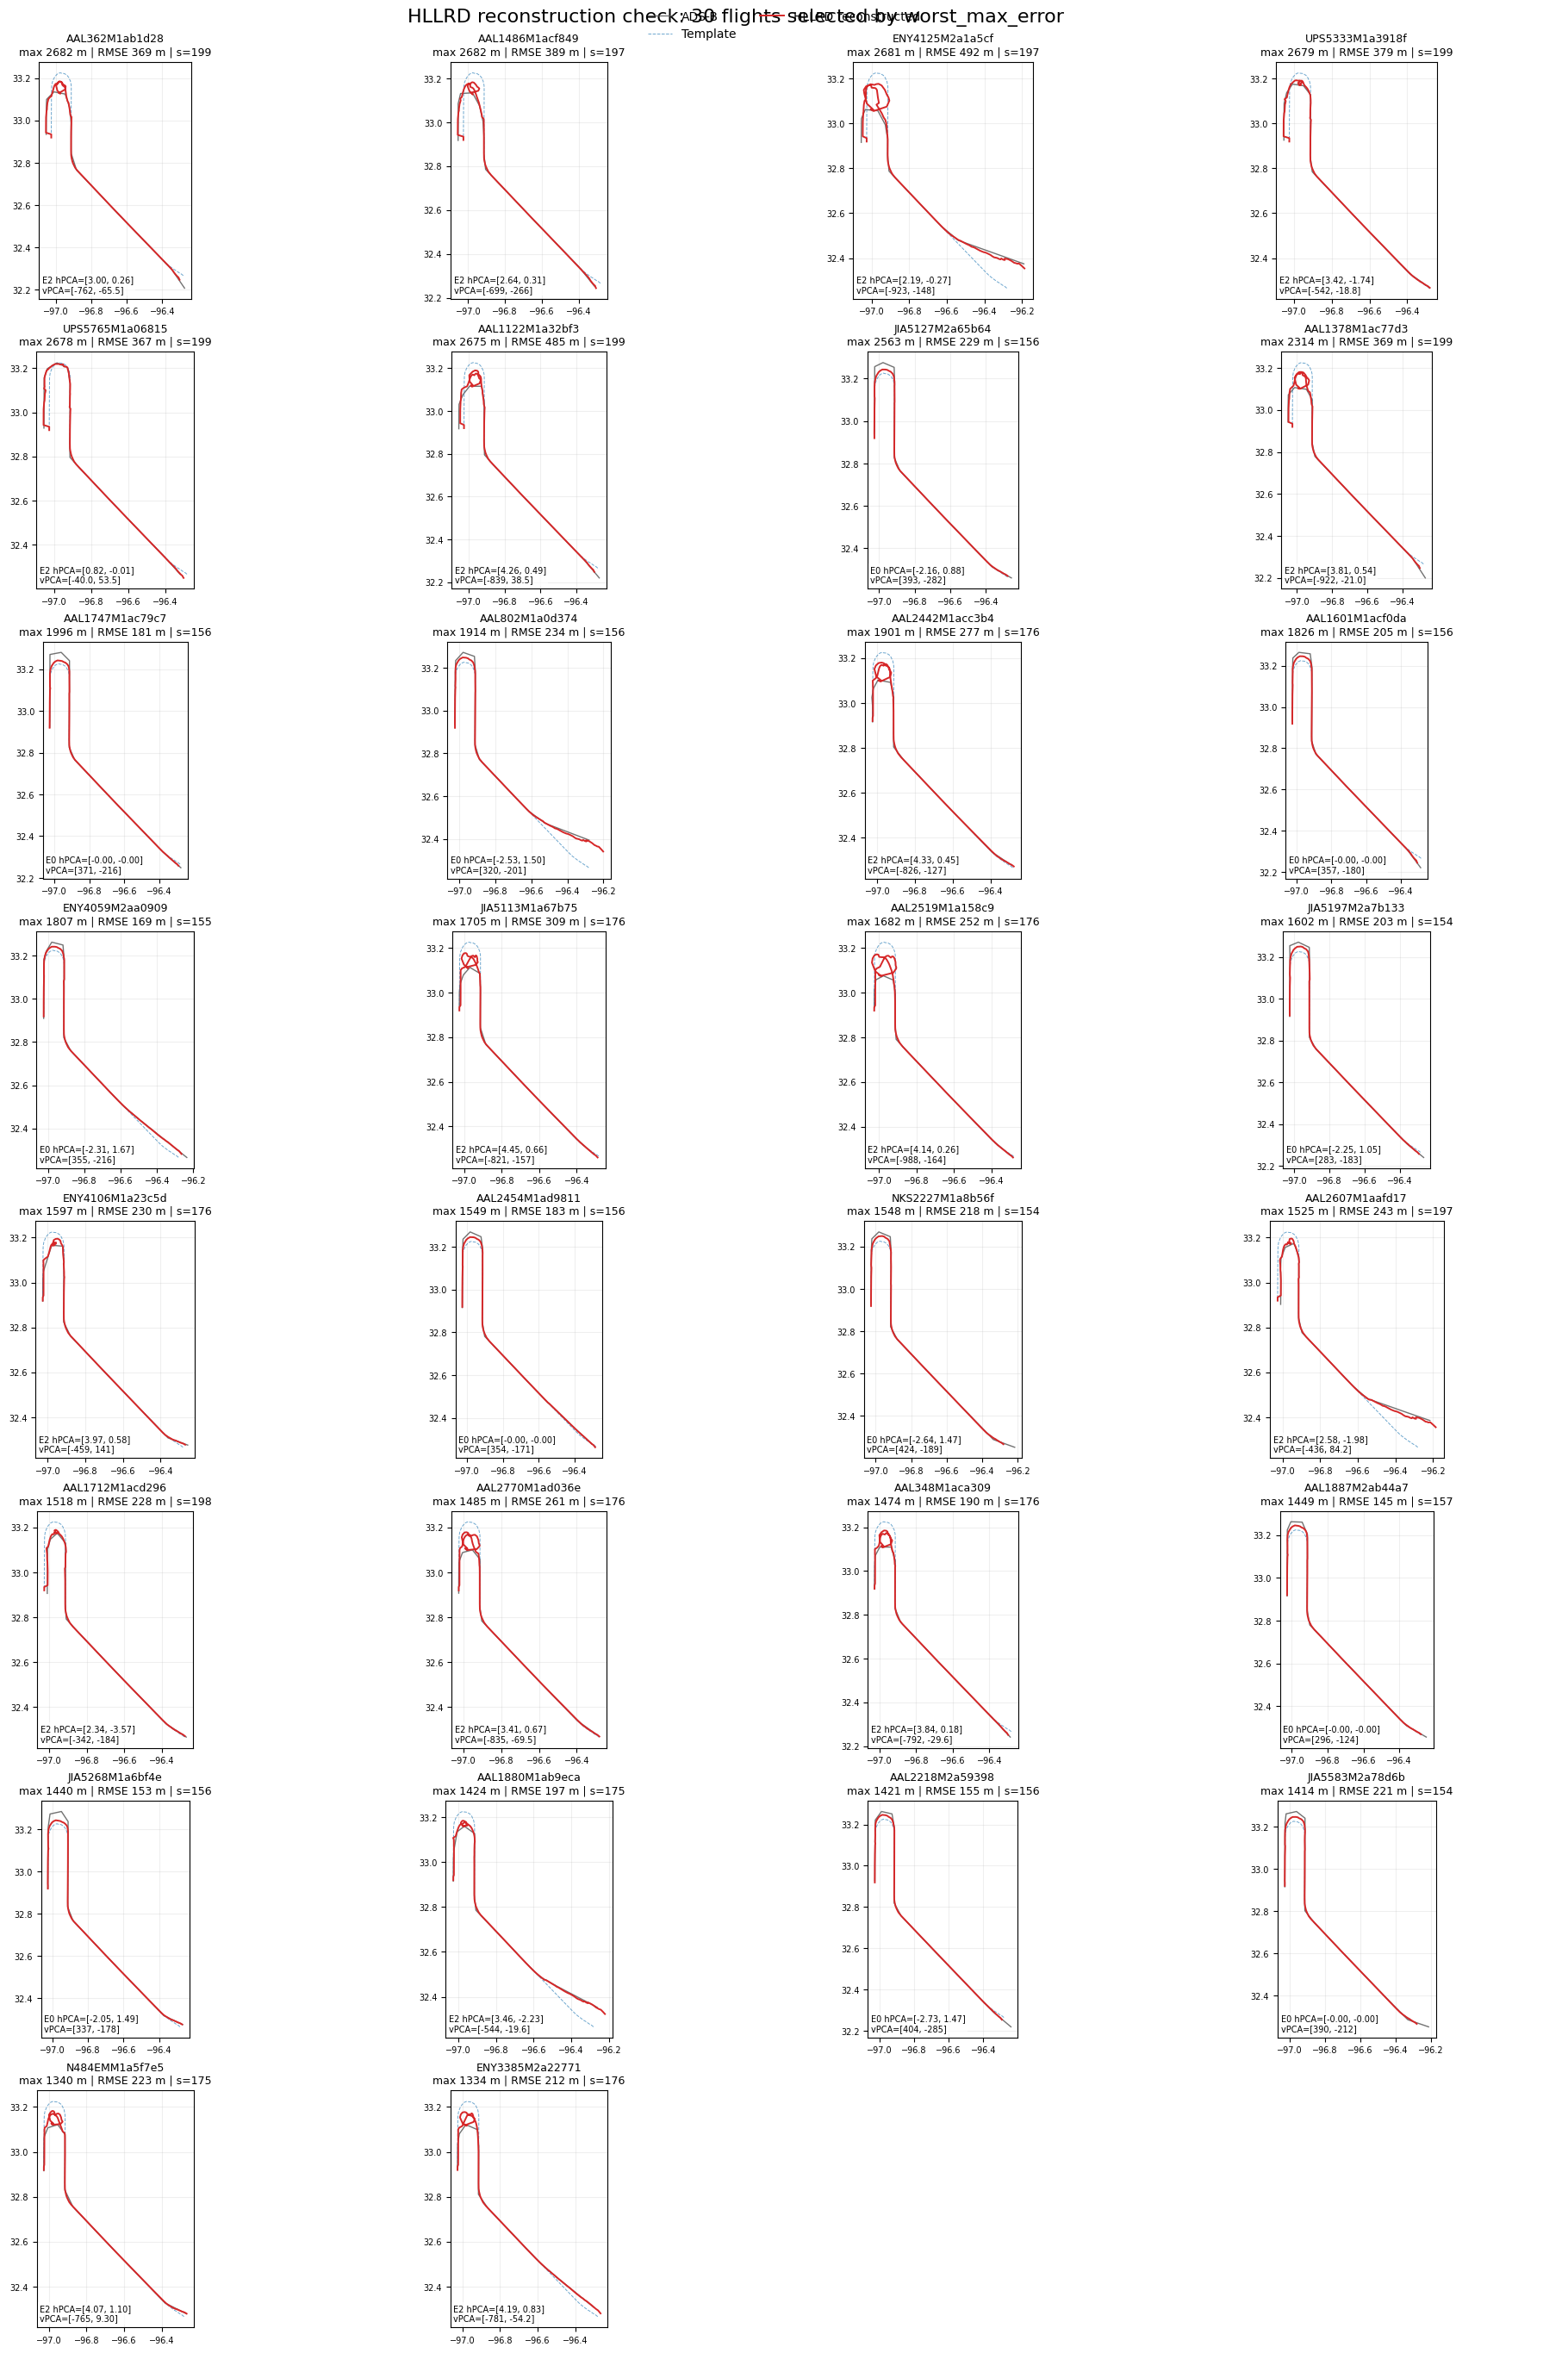

In [8]:
fig, axes = plt.subplots(ROWS, COLS, figsize=(4.8 * COLS, 3.4 * ROWS), constrained_layout=True)
axes_flat = np.asarray(axes).ravel()
template_lat, template_lon = template_latlon()

for ax, row in zip(axes_flat, selected_flights.itertuples(index=False), strict=False):
    row_index = int(row.row_index)
    flight_id = str(row.flight_id)

    if flight_id in raw_tracks_by_flight:
        raw = raw_tracks_by_flight[flight_id]
        ax.plot(raw["lon"], raw["lat"], color="0.35", linewidth=1.0, alpha=0.85, label="ADS-B")
    else:
        original_lat, original_lon = matrix_original_latlon(row_index)
        ax.plot(original_lon, original_lat, color="0.35", linewidth=1.0, alpha=0.85, label="Matrix original")

    ax.plot(template_lon, template_lat, color="#1f77b4", linewidth=0.7, linestyle="--", alpha=0.65, label="Template")

    rec_lat, rec_lon = reconstructed_latlon(row_index)
    ax.plot(rec_lon, rec_lat, color="#d62728", linewidth=1.4, label="HLLRD reconstructed")

    max_err = float(row.max_abs_cross_track_error_m)
    rmse = float(row.rmse_cross_track_error_m)
    station = int(row.station_at_max_error)
    ax.set_title(f"{flight_id}\nmax {max_err:.0f} m | RMSE {rmse:.0f} m | s={station}", fontsize=9)
    score_label = pca_score_label(row_index, station)
    if score_label:
        ax.text(
            0.02,
            0.02,
            score_label,
            transform=ax.transAxes,
            ha="left",
            va="bottom",
            fontsize=7,
            bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.72, "pad": 1.5},
        )
    ax.grid(True, alpha=0.2)
    ax.tick_params(labelsize=7)
    axis_equal_lonlat(ax)

for ax in axes_flat[len(selected_flights) :]:
    ax.axis("off")

handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)
fig.suptitle(
    f"HLLRD reconstruction check: {len(selected_flights)} flights selected by {SELECTION}",
    fontsize=16,
)

SAVE_FIGURE_PATH.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(SAVE_FIGURE_PATH, dpi=170, bbox_inches="tight")
print(f"Saved figure to {SAVE_FIGURE_PATH}")
plt.show()

## Error Distribution

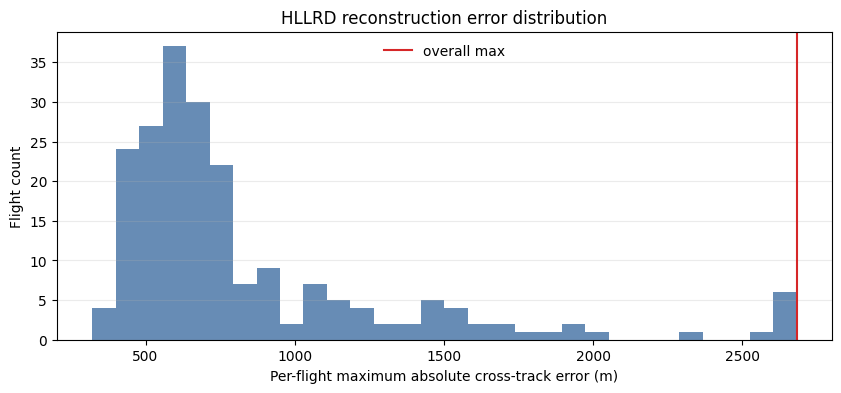

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(per_flight_error["max_abs_cross_track_error_m"], bins=30, color="#4c78a8", alpha=0.85)
ax.axvline(overall_error.loc[0, "max_abs_cross_track_error_m"], color="#d62728", linewidth=1.5, label="overall max")
ax.set_xlabel("Per-flight maximum absolute cross-track error (m)")
ax.set_ylabel("Flight count")
ax.set_title("HLLRD reconstruction error distribution")
ax.grid(True, axis="y", alpha=0.25)
ax.legend(frameon=False)
plt.show()